## Importing the required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('../data/futuristic_city_traffic.csv')
df.head()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,118.8000,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,76.8000,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544


In [3]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

## COLUMNS DESCRIPTION

City – The location of the observation. Useful for comparing patterns across different cities. Could be categorical.

Vehicle Type – Type of vehicle (e.g., car, bus, truck). Important for energy consumption and traffic analysis. Categorical variable.

Weather – Weather conditions during the observation (e.g., sunny, rainy, snowy). Impacts speed, energy consumption, and traffic density. Categorical.

Economic Condition – Possibly reflects city-level economic activity or status. Can affect traffic patterns. Categorical.

Day Of Week – Monday to Sunday. Helps identify weekday vs weekend trends. Categorical.

Hour Of Day – Numeric (0–23). Important for peak vs off-peak analysis.

Speed – Average speed of vehicles. Numeric. Could be influenced by traffic, weather, or time of day.

Is Peak Hour – Binary (Yes/No or 1/0). Useful for classifying traffic periods.

Random Event Occurred – Binary (Yes/No). Captures events like accidents or roadblocks that affect traffic and energy consumption.

Energy Consumption – Numeric. Could be fuel consumption or electricity for EVs. This could be your target variable in a regression model.

Traffic Density – Numeric or categorical (e.g., low, medium, high). Could be predicted from other features or used as another target variable.

In [4]:
df.shape  ## dataset shape

(1219567, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219567 entries, 0 to 1219566
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   City                   1219567 non-null  object 
 1   Vehicle Type           1219567 non-null  object 
 2   Weather                1219567 non-null  object 
 3   Economic Condition     1219567 non-null  object 
 4   Day Of Week            1219567 non-null  object 
 5   Hour Of Day            1219567 non-null  int64  
 6   Speed                  1219567 non-null  float64
 7   Is Peak Hour           1219567 non-null  int64  
 8   Random Event Occurred  1219567 non-null  int64  
 9   Energy Consumption     1219567 non-null  float64
 10  Traffic Density        1219567 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 102.4+ MB


In [6]:
df.describe()

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
count,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06
mean,1.150817e+01,5.994476e+01,1.546992e-01,4.988738e-02,4.946464e+01,2.770960e-01
std,6.919071e+00,2.663203e+01,3.616178e-01,2.177123e-01,2.528014e+01,2.191019e-01
min,0.000000e+00,6.693400e+00,0.000000e+00,0.000000e+00,4.929600e+00,5.900000e-03
25%,6.000000e+00,3.753310e+01,0.000000e+00,0.000000e+00,2.927395e+01,1.059000e-01
50%,1.200000e+01,5.847110e+01,0.000000e+00,0.000000e+00,4.578260e+01,2.186000e-01
75%,1.700000e+01,8.053455e+01,0.000000e+00,0.000000e+00,6.590550e+01,3.960000e-01
max,2.300000e+01,1.630886e+02,1.000000e+00,1.000000e+00,1.899489e+02,3.377600e+00


## Data Cleaning

In [7]:
df.isnull().sum()

City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Removing Outliers

<Axes: >

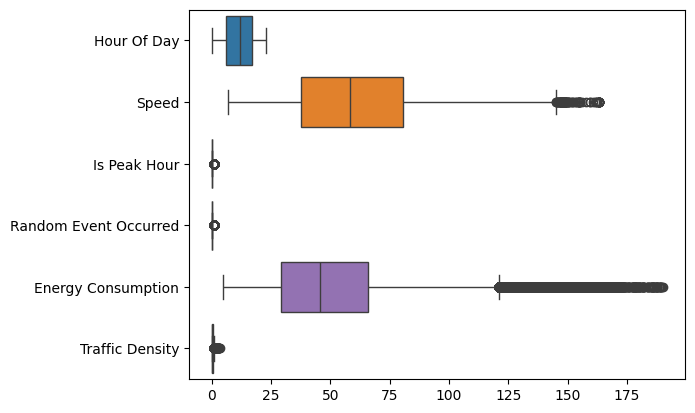

In [9]:
sns.boxplot(df,orient='h')

In [10]:
num_cols = df.select_dtypes(exclude='object')

In [11]:
## outliers remove function

def remove_outliers(df,col):
    q1 = df[col].quantile(0.05)
    q3 = df[col].quantile(0.60)
    iqr = q3-q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

for col in num_cols:
    df = remove_outliers(df,col)

<Axes: >

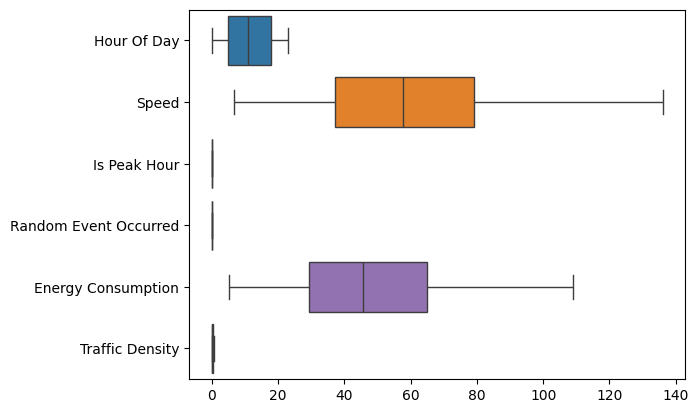

In [12]:
sns.boxplot(df,orient='h')

In [13]:
df.shape

(889778, 11)

## Univariate Analysis

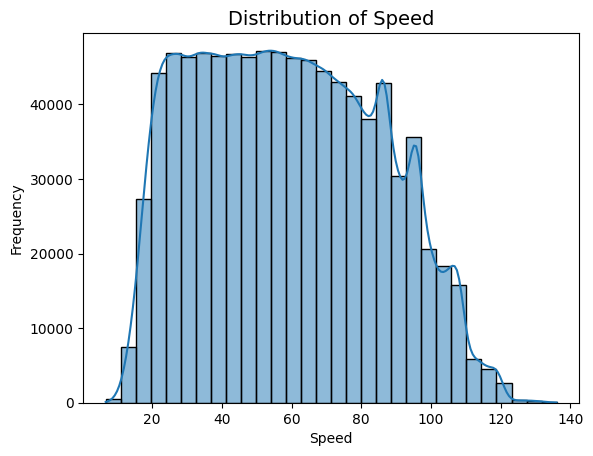

In [14]:
sns.histplot(df['Speed'], kde=True, bins=30)
plt.title(f"Distribution of Speed", fontsize=14)
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()


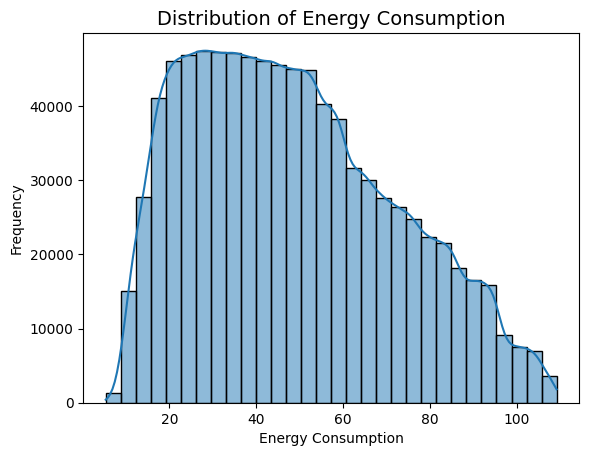

In [15]:
sns.histplot(df['Energy Consumption'],kde=True,bins=30)
plt.title("Distribution of Energy Consumption",fontsize=14)
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.show()

In [16]:
df['Hour Of Day'].value_counts()

Hour Of Day
15    44520
11    44389
16    44388
20    44165
10    44141
5     43915
21    43911
4     43854
9     43805
23    43774
1     43708
22    43684
0     43684
19    43560
2     43416
6     43315
3     43188
13    32056
14    31577
12    31364
17    12495
8     12464
7     12227
18    12178
Name: count, dtype: int64

In [17]:
df.head()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544
5,TechHaven,Autonomous Vehicle,Snowy,Recession,Thursday,20,30.5179,0,0,37.5562,0.0843
6,Ecoopolis,Autonomous Vehicle,Rainy,Recession,Monday,21,43.9222,0,0,39.0420,0.0293


In [18]:
df['Is Peak Hour'].value_counts()

Is Peak Hour
0    889778
Name: count, dtype: int64

In [19]:
df['Random Event Occurred'].value_counts()

Random Event Occurred
0    889778
Name: count, dtype: int64

<Axes: xlabel='Speed', ylabel='Energy Consumption'>

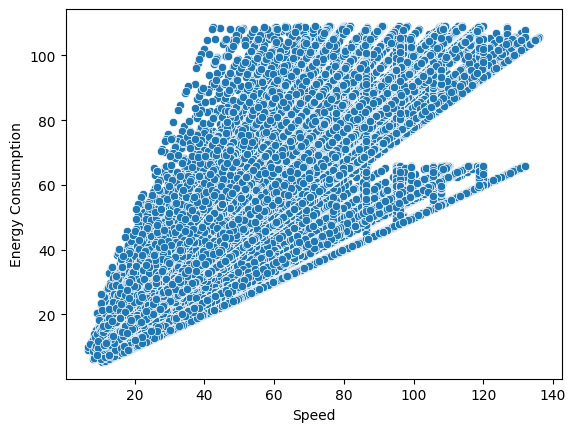

In [20]:
sns.scatterplot(x='Speed', y='Energy Consumption', data=df)

<Axes: >

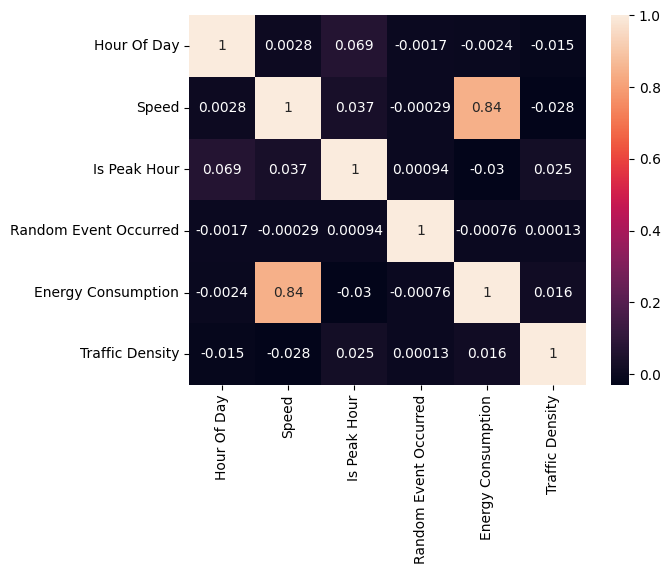

In [21]:
sns.heatmap(num_cols.corr(),annot=True)

In [22]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

In [23]:
y = df['Energy Consumption']
x = df.drop(columns=['Energy Consumption'])

## Splitting and Preprocessing

In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20)

In [25]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889778 entries, 0 to 1219565
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   889778 non-null  object 
 1   Vehicle Type           889778 non-null  object 
 2   Weather                889778 non-null  object 
 3   Economic Condition     889778 non-null  object 
 4   Day Of Week            889778 non-null  object 
 5   Hour Of Day            889778 non-null  int64  
 6   Speed                  889778 non-null  float64
 7   Is Peak Hour           889778 non-null  int64  
 8   Random Event Occurred  889778 non-null  int64  
 9   Traffic Density        889778 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 74.7+ MB


## Creating Pipeline

In [26]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor



categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns

numeric_cols = x_train.select_dtypes(exclude=['object']).columns



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

pipe = make_pipeline(preprocessor, KNeighborsRegressor())


In [27]:
pipe.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('kneighborsregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred = pipe.predict(x_test)

In [29]:
from sklearn.metrics import r2_score

print(r2_score(y_test,y_pred))

0.9642141894136642


## Model PipeLine and Hyperparameter Tuning

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Model tuning Parameters 

In [ ]:

dt_params = {
    'criterion': ['squared_error','friedman_mse','absolute_error'],
    'min_samples_split': [2, 3, 4, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7],
    'min_samples_leaf': [2, 3, 4, 5, 6]
}

lr_params = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga', 'lbfgs']
}

]
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10, 15, None],
    'max_features': [5, 7, 8,],
    'min_samples_split': [2, 8, 15, 20]
}


xg_params = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1.0]
}


gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 1.0],
    
}


# Hyperparamter Tuning

### Linear Regression Tuning